# Deforestation Detection — Model Training

**Reference:** Das et al., "A Deforestation Detection Network Using Deep Learning-Based Semantic Segmentation" (IEEE Sensors Letters, 2024)

---

## Models Implemented

| # | Model | Description |
|---|-------|-------------|
| 1 | UNet | Symmetric U-shaped encoder-decoder |
| 2 | ResNet18-based Modified SegNet | SegNet with ResNet18 encoder (residual learning + skip connections) |
| 3 | ShuffleNet-based Modified SegNet | SegNet with ShuffleNet encoder (group conv + channel shuffle) |
| 4 | **Proposed Ensemble** | Pixel-wise majority voting of models 1, 2, 3 |

**Dataset:** Preprocessed chips from `main.ipynb` (Sentinel-2, South Kalimantan)  
**Classes:** 0 = Non-forest, 1 = Forest, 2 = Deforested  
**Training:** Single run, 25 epochs per model, train/val/test split  
**Metrics:** Recall, Precision, IoU, Dice

---

## 0. Setup & Configuration

In [2]:
import json, gc, time, logging, warnings
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(message)s',
    datefmt='%H:%M:%S',
)
log = logging.getLogger(__name__)

print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch: 2.9.0+cu130
CUDA available: True
GPU: NVIDIA GeForce RTX 3080


In [3]:
@dataclass
class TrainConfig:
    # --- Paths (must match main.ipynb output) ---
    data_dir: Path = Path("Dataset/Kalsel_Processed")
    results_dir: Path = Path("Results")

    # --- Dataset selection ---
    variant: str = "none"          # Inpainting variant: none / telea / biharmonic / pix2pix
    composition: str = "NGB"       # Band composition: NGB / NDVI / EVI
    num_classes: int = 3           # 0=Non-forest, 1=Forest, 2=Deforested

    # --- Training ---
    epochs: int = 10
    batch_size: int = 8
    lr: float = 1e-3
    weight_decay: float = 1e-4
    scheduler_patience: int = 5
    early_stop_patience: int = 10
    seed: int = 42

    @property
    def in_channels(self):
        return {'NGB': 3, 'NDVI': 1, 'EVI': 1}[self.composition]

    @property
    def device(self):
        return torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    def __post_init__(self):
        self.results_dir.mkdir(parents=True, exist_ok=True)


cfg = TrainConfig()
log.info(f'Data: {cfg.data_dir}')
log.info(f'Variant: {cfg.variant}, Composition: {cfg.composition}')
log.info(f'In channels: {cfg.in_channels}, Classes: {cfg.num_classes}')
log.info(f'Device: {cfg.device}')

19:09:58 | INFO | Data: Dataset\Kalsel_Processed
19:09:58 | INFO | Variant: none, Composition: NGB
19:09:58 | INFO | In channels: 3, Classes: 3
19:09:58 | INFO | Device: cuda


---
## 1. Dataset

Loads preprocessed `.npz` chips from the output of `main.ipynb`.

In [4]:
class DeforestationDataset(Dataset):
    """Loads preprocessed chips from .npz files."""
    def __init__(self, chip_dir):
        self.files = sorted(Path(chip_dir).glob('*.npz'))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        data = np.load(self.files[idx])
        image = data['image'].copy()   # (C, H, W) float32 [0,1]
        mask = data['mask'].copy()     # (H, W) uint8 {0,1,2}
        return {
            'image': torch.from_numpy(image),
            'mask': torch.from_numpy(mask.astype(np.int64)),
        }


# Verify dataset loading
data_path = cfg.data_dir / cfg.variant / cfg.composition
log.info(f'Data path: {data_path}')

for split in ['train', 'val', 'test']:
    split_dir = data_path / split
    if split_dir.exists():
        n = len(list(split_dir.glob('*.npz')))
        log.info(f'  {split}: {n} chips')
    else:
        log.warning(f'  {split}: NOT FOUND')

19:10:01 | INFO | Data path: Dataset\Kalsel_Processed\none\NGB
19:10:01 | INFO |   train: 11682 chips
19:10:01 | INFO |   val: 3909 chips
19:10:01 | INFO |   test: 3975 chips


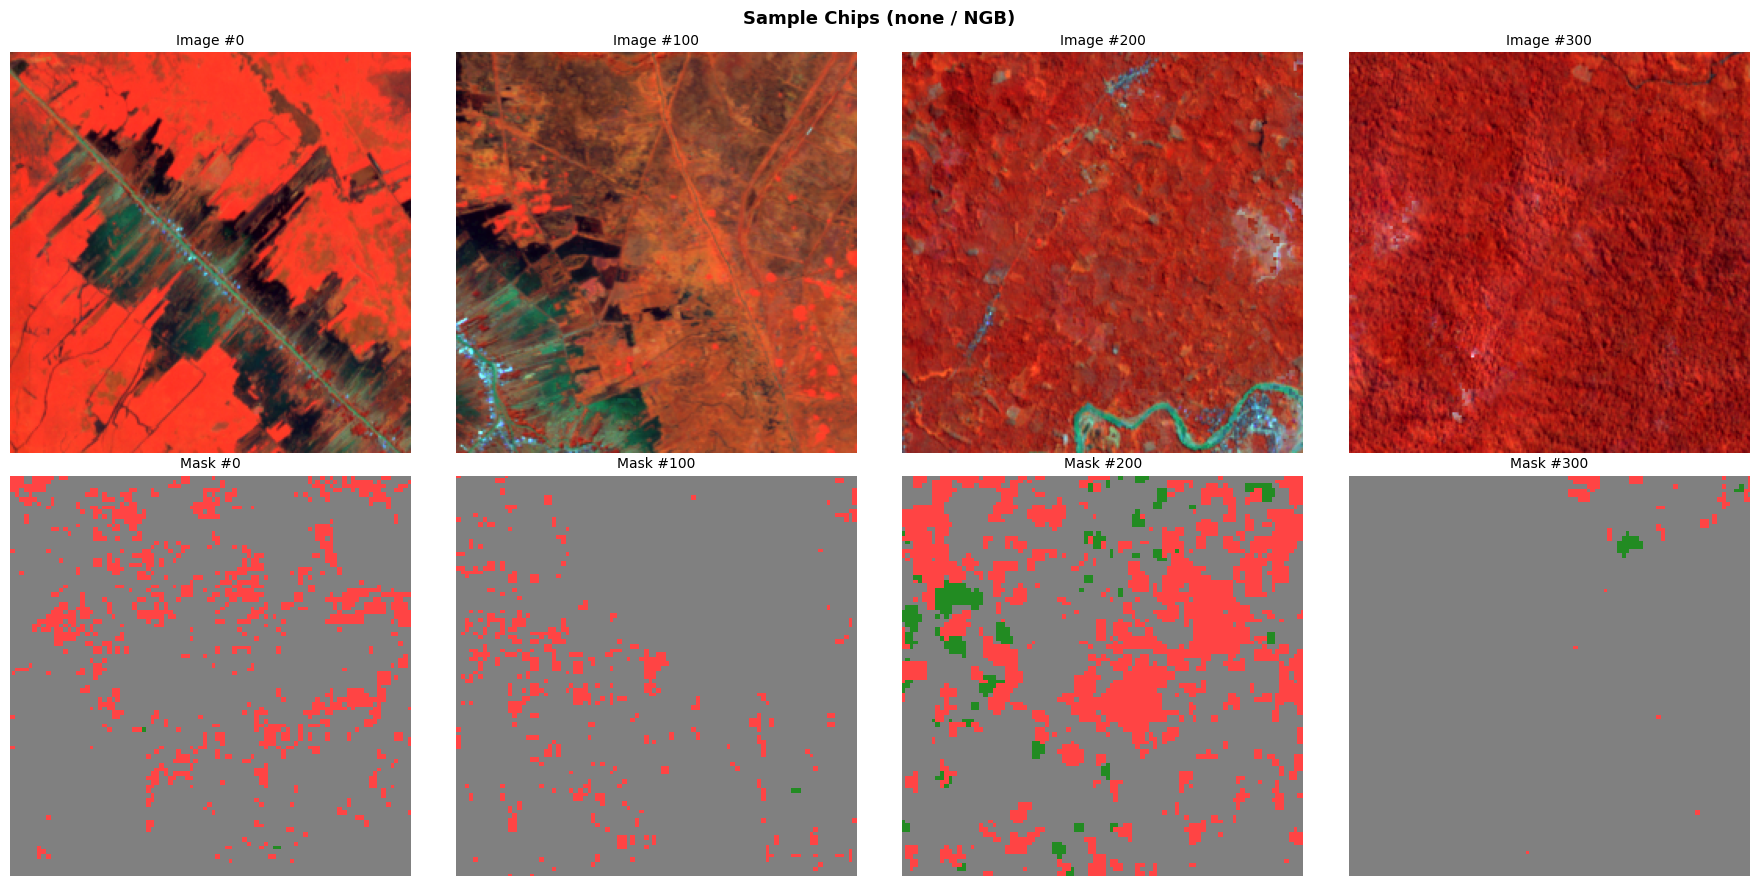

26

In [5]:
# Visualize sample chips
mask_cmap = ListedColormap(['#808080', '#228B22', '#FF4444'])

sample_ds = DeforestationDataset(data_path / 'train')

if len(sample_ds) > 0:
    fig, axes = plt.subplots(2, 4, figsize=(18, 9))
    for i in range(4):
        idx = min(i * 100, len(sample_ds) - 1)
        sample = sample_ds[idx]
        img = sample['image'].numpy()
        mask = sample['mask'].numpy()

        if img.shape[0] >= 3:
            axes[0, i].imshow(np.clip(np.transpose(img, (1,2,0)), 0, 1))
        else:
            axes[0, i].imshow(img[0], cmap='RdYlGn', vmin=0, vmax=1)

        axes[1, i].imshow(mask, cmap=mask_cmap, vmin=0, vmax=2, interpolation='nearest')

        axes[0, i].set_title(f'Image #{idx}', fontsize=10)
        axes[1, i].set_title(f'Mask #{idx}', fontsize=10)
        axes[0, i].axis('off')
        axes[1, i].axis('off')

    fig.suptitle(f'Sample Chips ({cfg.variant} / {cfg.composition})',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(cfg.results_dir / 'sample_chips.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    log.warning('No training data found.')

del sample_ds
gc.collect()

---
## 2. Model Architectures

Four models from the paper, implemented in PyTorch.

### 2.1 UNet

In [6]:
class UNet(nn.Module):
    """
    UNet: Symmetric U-shaped encoder-decoder with skip connections.
    Uses upsampling operators instead of pooling (as noted in the paper, Section II-D).
    Reference: Ronneberger et al., "U-Net: Convolutional Networks for Biomedical
    Image Segmentation"
    """
    def __init__(self, in_channels=3, num_classes=3):
        super().__init__()

        # Contracting path
        self.enc1 = self._double_conv(in_channels, 64)
        self.enc2 = self._double_conv(64, 128)
        self.enc3 = self._double_conv(128, 256)
        self.enc4 = self._double_conv(256, 512)

        # Bottleneck
        self.bottleneck = self._double_conv(512, 1024)

        # Expanding path
        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = self._double_conv(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = self._double_conv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = self._double_conv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = self._double_conv(128, 64)

        self.classifier = nn.Conv2d(64, num_classes, 1)
        self.pool = nn.MaxPool2d(2, 2)

    def _double_conv(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        # Bottleneck
        b = self.bottleneck(self.pool(e4))

        # Decoder with skip connections
        d4 = self.up4(b)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))

        d3 = self.up3(d4)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.classifier(d1)


print('UNet defined.')

UNet defined.


### 2.2 ResNet18-based Modified SegNet

From the paper (Section II-B): Uses ResNet18 as the encoder instead of VGG16.  
Key advantages: **residual learning** + **skip connections** → faster convergence, avoids vanishing gradients.

In [7]:
class ResidualBlock(nn.Module):
    """Basic residual block with skip connection (ResNet18 style)."""
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)), inplace=True)
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return F.relu(out, inplace=True)


class ResNet18ModifiedSegNet(nn.Module):
    """
    Modified SegNet with ResNet18 encoder (Section II-B).

    Encoder: ResNet18 architecture
      - Conv 7x7/64, stride 2 -> MaxPool 3x3, stride 2
      - 2x ResBlock(64) -> 2x ResBlock(128) -> 2x ResBlock(256) -> 2x ResBlock(512)
    Decoder: SegNet-style with max unpooling indices
      - Upsampling + Conv + BN + ReLU + Softmax

    Advantages (from paper):
    - Residual learning: network learns residual mappings, easier optimization
    - Skip connections: gradient flows through shortcuts, avoids vanishing gradient
    - Converges faster than standard SegNet with VGG16
    """
    def __init__(self, in_channels=3, num_classes=3):
        super().__init__()

        # === Encoder (ResNet18) ===
        # Initial conv: 7x7, 64 filters, stride 2 (as described in paper)
        self.initial = nn.Sequential(
            nn.Conv2d(in_channels, 64, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )
        # MaxPool 3x3, stride 2
        # Using return_indices for SegNet-style decoder

        # Residual blocks: 2 blocks each of [64, 128, 256, 512]
        self.layer1 = nn.Sequential(ResidualBlock(64, 64), ResidualBlock(64, 64))
        self.layer2 = nn.Sequential(ResidualBlock(64, 128, stride=2), ResidualBlock(128, 128))
        self.layer3 = nn.Sequential(ResidualBlock(128, 256, stride=2), ResidualBlock(256, 256))
        self.layer4 = nn.Sequential(ResidualBlock(256, 512, stride=2), ResidualBlock(512, 512))

        # === Decoder (SegNet-style) ===
        self.dec4 = self._decoder_block(512, 256)
        self.dec3 = self._decoder_block(256, 128)
        self.dec2 = self._decoder_block(128, 64)
        self.dec1 = self._decoder_block(64, 64)
        self.dec0 = self._decoder_block(64, 64)

        self.classifier = nn.Conv2d(64, num_classes, 1)

    def _decoder_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, in_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(in_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        input_size = x.shape[2:]

        # Encoder
        x0 = self.initial(x)                    # /2
        x0p, idx0 = F.max_pool2d(x0, 3, 2, 1, return_indices=True)  # /4

        x1 = self.layer1(x0p)                   # /4, 64ch
        x2 = self.layer2(x1)                    # /8, 128ch
        x3 = self.layer3(x2)                    # /16, 256ch
        x4 = self.layer4(x3)                    # /32, 512ch

        # Decoder with upsampling
        d4 = F.interpolate(x4, size=x3.shape[2:], mode='bilinear', align_corners=True)
        d4 = self.dec4(d4)                      # /16, 256ch

        d3 = F.interpolate(d4, size=x2.shape[2:], mode='bilinear', align_corners=True)
        d3 = self.dec3(d3)                      # /8, 128ch

        d2 = F.interpolate(d3, size=x1.shape[2:], mode='bilinear', align_corners=True)
        d2 = self.dec2(d2)                      # /4, 64ch

        d1 = F.max_unpool2d(d2, idx0, 3, 2, 1, output_size=x0.shape)
        d1 = self.dec1(d1)                      # /2, 64ch

        d0 = F.interpolate(d1, size=input_size, mode='bilinear', align_corners=True)
        d0 = self.dec0(d0)                      # /1, 64ch

        return self.classifier(d0)


print('ResNet18-based Modified SegNet defined.')

ResNet18-based Modified SegNet defined.


### 2.3 ShuffleNet-based Modified SegNet

From the paper (Section II-C): Uses ShuffleNet as the encoder.  
Key advantages: **pointwise group convolution** + **channel shuffling** → fewer parameters, computationally efficient.

In [8]:
class ChannelShuffle(nn.Module):
    """Channel shuffle operation (key innovation of ShuffleNet).
    Mixes feature maps across groups after group convolution."""
    def __init__(self, groups):
        super().__init__()
        self.groups = groups

    def forward(self, x):
        b, c, h, w = x.shape
        g = self.groups
        x = x.view(b, g, c // g, h, w)
        x = x.permute(0, 2, 1, 3, 4).contiguous()
        return x.view(b, c, h, w)


class ShuffleUnit(nn.Module):
    """
    ShuffleNet unit: pointwise group conv -> channel shuffle -> depthwise conv -> pointwise group conv.
    Reduces computational cost by factorizing convolutions.
    """
    def __init__(self, in_ch, out_ch, groups=3, stride=1):
        super().__init__()
        mid_ch = out_ch // 4
        self.stride = stride

        # 1x1 group convolution
        self.gconv1 = nn.Sequential(
            nn.Conv2d(in_ch, mid_ch, 1, groups=groups if in_ch % groups == 0 else 1, bias=False),
            nn.BatchNorm2d(mid_ch),
            nn.ReLU(inplace=True),
        )
        self.shuffle = ChannelShuffle(groups)

        # 3x3 depthwise convolution
        self.dwconv = nn.Sequential(
            nn.Conv2d(mid_ch, mid_ch, 3, stride=stride, padding=1, groups=mid_ch, bias=False),
            nn.BatchNorm2d(mid_ch),
        )

        # 1x1 group convolution
        self.gconv2 = nn.Sequential(
            nn.Conv2d(mid_ch, out_ch, 1, groups=groups if mid_ch % groups == 0 else 1, bias=False),
            nn.BatchNorm2d(out_ch),
        )

        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )

    def forward(self, x):
        out = self.gconv1(x)
        out = self.shuffle(out)
        out = self.dwconv(out)
        out = self.gconv2(out)
        out = out + self.shortcut(x)
        return F.relu(out, inplace=True)


class ShuffleNetModifiedSegNet(nn.Module):
    """
    Modified SegNet with ShuffleNet encoder (Section II-C).

    Encoder: ShuffleNet architecture
      - Group convolutions reduce computation
      - Channel shuffling enables cross-group information flow
    Decoder: SegNet-style with upsampling + convolution

    Advantages (from paper):
    - Pointwise group convolution: reduces parameters
    - Channel shuffling: mixes features across groups
    - Fewer FLOPs while maintaining accuracy
    """
    def __init__(self, in_channels=3, num_classes=3, groups=3):
        super().__init__()

        # === Encoder (ShuffleNet) ===
        self.initial = nn.Sequential(
            nn.Conv2d(in_channels, 24, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(24),
            nn.ReLU(inplace=True),
        )

        # Stage 2: 24 -> 120
        self.stage2 = nn.Sequential(
            ShuffleUnit(24, 120, groups=groups, stride=2),
            ShuffleUnit(120, 120, groups=groups),
            ShuffleUnit(120, 120, groups=groups),
        )
        # Stage 3: 120 -> 240
        self.stage3 = nn.Sequential(
            ShuffleUnit(120, 240, groups=groups, stride=2),
            ShuffleUnit(240, 240, groups=groups),
            ShuffleUnit(240, 240, groups=groups),
        )
        # Stage 4: 240 -> 480
        self.stage4 = nn.Sequential(
            ShuffleUnit(240, 480, groups=groups, stride=2),
            ShuffleUnit(480, 480, groups=groups),
            ShuffleUnit(480, 480, groups=groups),
        )

        # === Decoder (SegNet-style) ===
        self.dec4 = self._decoder_block(480, 240)
        self.dec3 = self._decoder_block(240, 120)
        self.dec2 = self._decoder_block(120, 24)
        self.dec1 = self._decoder_block(24, 24)

        self.classifier = nn.Conv2d(24, num_classes, 1)

    def _decoder_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, in_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(in_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        input_size = x.shape[2:]

        # Encoder
        x0 = self.initial(x)       # /2, 24ch
        x1 = self.stage2(x0)       # /4, 120ch
        x2 = self.stage3(x1)       # /8, 240ch
        x3 = self.stage4(x2)       # /16, 480ch

        # Decoder
        d3 = F.interpolate(x3, size=x2.shape[2:], mode='bilinear', align_corners=True)
        d3 = self.dec4(d3)         # /8, 240ch

        d2 = F.interpolate(d3, size=x1.shape[2:], mode='bilinear', align_corners=True)
        d2 = self.dec3(d2)         # /4, 120ch

        d1 = F.interpolate(d2, size=x0.shape[2:], mode='bilinear', align_corners=True)
        d1 = self.dec2(d1)         # /2, 24ch

        d0 = F.interpolate(d1, size=input_size, mode='bilinear', align_corners=True)
        d0 = self.dec1(d0)         # /1, 24ch

        return self.classifier(d0)


print('ShuffleNet-based Modified SegNet defined.')

ShuffleNet-based Modified SegNet defined.


### 2.4 Proposed Ensemble (Pixel-wise Majority Voting)

From the paper (Section II): The final predicted output is based on **pixel-wise majority voting** of:
1. UNet
2. ResNet18-based Modified SegNet
3. ShuffleNet-based Modified SegNet

This integrates the advantages of all three models for improved accuracy and robustness.

In [9]:
class ProposedEnsemble(nn.Module):
    """
    Proposed semantic segmentation framework (Section II, Fig. 1).

    Ensembles three models via pixel-wise majority voting:
    1. UNet (symmetric architecture, upsampling operators)
    2. ResNet18-based Modified SegNet (residual learning, skip connections)
    3. ShuffleNet-based Modified SegNet (group conv, channel shuffle)

    The combined benefits improve overall accuracy and robustness.
    """
    def __init__(self, unet, resnet_segnet, shuffle_segnet):
        super().__init__()
        self.unet = unet
        self.resnet_segnet = resnet_segnet
        self.shuffle_segnet = shuffle_segnet

    def forward(self, x):
        """During training, return average logits for differentiable training."""
        out1 = self.unet(x)
        out2 = self.resnet_segnet(x)
        out3 = self.shuffle_segnet(x)
        # Average logits (soft voting for training)
        return (out1 + out2 + out3) / 3.0

    def predict_majority(self, x):
        """
        Pixel-wise majority voting for inference (as described in paper).
        Each model predicts a class per pixel, final = majority vote.
        """
        with torch.no_grad():
            pred1 = self.unet(x).argmax(dim=1)           # (B, H, W)
            pred2 = self.resnet_segnet(x).argmax(dim=1)  # (B, H, W)
            pred3 = self.shuffle_segnet(x).argmax(dim=1) # (B, H, W)

            # Stack predictions and take mode (majority vote)
            stacked = torch.stack([pred1, pred2, pred3], dim=0)  # (3, B, H, W)
            majority = torch.mode(stacked, dim=0).values         # (B, H, W)
        return majority


print('Proposed Ensemble (majority voting) defined.')

Proposed Ensemble (majority voting) defined.


### Model Summary

In [10]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def verify_model(model_class, name, in_ch, n_cls):
    model = model_class(in_channels=in_ch, num_classes=n_cls)
    model.eval()
    x = torch.randn(1, in_ch, 256, 256)
    with torch.no_grad():
        y = model(x)
    params = count_params(model)
    print(f'{name:<35s} | params: {params:>10,} | in: {list(x.shape)} -> out: {list(y.shape)}')
    assert y.shape == (1, n_cls, 256, 256), f'Output shape mismatch: {y.shape}'
    del model, x, y
    return params

print(f'Input channels: {cfg.in_channels}, Classes: {cfg.num_classes}')
print('=' * 90)

models_info = {}
for cls, name in [
    (UNet, 'UNet'),
    (ResNet18ModifiedSegNet, 'ResNet18-Modified SegNet'),
    (ShuffleNetModifiedSegNet, 'ShuffleNet-Modified SegNet'),
]:
    p = verify_model(cls, name, cfg.in_channels, cfg.num_classes)
    models_info[name] = p

# Verify ensemble
unet = UNet(cfg.in_channels, cfg.num_classes)
rn_seg = ResNet18ModifiedSegNet(cfg.in_channels, cfg.num_classes)
sh_seg = ShuffleNetModifiedSegNet(cfg.in_channels, cfg.num_classes)
ensemble = ProposedEnsemble(unet, rn_seg, sh_seg)
ensemble.eval()
x = torch.randn(1, cfg.in_channels, 256, 256)
with torch.no_grad():
    y_avg = ensemble(x)
    y_maj = ensemble.predict_majority(x)
p_ens = count_params(ensemble)
print(f'{"Proposed Ensemble":<35s} | params: {p_ens:>10,} | logits: {list(y_avg.shape)}, majority: {list(y_maj.shape)}')
del unet, rn_seg, sh_seg, ensemble, x
gc.collect()

print('\nAll models verified successfully.')

Input channels: 3, Classes: 3
UNet                                | params: 31,037,763 | in: [1, 3, 256, 256] -> out: [1, 3, 256, 256]
ResNet18-Modified SegNet            | params: 15,972,227 | in: [1, 3, 256, 256] -> out: [1, 3, 256, 256]
ShuffleNet-Modified SegNet          | params:  4,357,233 | in: [1, 3, 256, 256] -> out: [1, 3, 256, 256]
Proposed Ensemble                   | params: 51,367,223 | logits: [1, 3, 256, 256], majority: [1, 256, 256]

All models verified successfully.


---
## 3. Training Infrastructure

Metrics from the paper: **Recall**, **Precision**, **IoU** (Intersection over Union), **Dice** coefficient.  

In [11]:
class SegmentationMetrics:
    """
    Computes per-class and mean metrics matching the paper's Tables 1-3:
    Recall (%), Precision (%), IoU, Dice coefficient.
    """
    def __init__(self, num_classes):
        self.num_classes = num_classes
        self.reset()

    def reset(self):
        self.tp = np.zeros(self.num_classes)
        self.fp = np.zeros(self.num_classes)
        self.fn = np.zeros(self.num_classes)

    def update(self, pred, target):
        """Update counts. pred and target are (B, H, W) integer tensors."""
        pred = pred.cpu().numpy().flatten()
        target = target.cpu().numpy().flatten()
        for c in range(self.num_classes):
            p = (pred == c)
            t = (target == c)
            self.tp[c] += np.sum(p & t)
            self.fp[c] += np.sum(p & ~t)
            self.fn[c] += np.sum(~p & t)

    def compute(self):
        eps = 1e-7
        recall = self.tp / (self.tp + self.fn + eps)
        precision = self.tp / (self.tp + self.fp + eps)
        iou = self.tp / (self.tp + self.fp + self.fn + eps)
        dice = 2 * self.tp / (2 * self.tp + self.fp + self.fn + eps)

        return {
            'recall_per_class': recall,
            'precision_per_class': precision,
            'iou_per_class': iou,
            'dice_per_class': dice,
            'recall': np.mean(recall) * 100,
            'precision': np.mean(precision) * 100,
            'iou': np.mean(iou),
            'dice': np.mean(dice),
        }


class DiceLoss(nn.Module):
    """Soft Dice loss for segmentation."""
    def __init__(self, num_classes, smooth=1.0):
        super().__init__()
        self.num_classes = num_classes
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        targets_oh = F.one_hot(targets, self.num_classes).permute(0, 3, 1, 2).float()
        dims = (0, 2, 3)
        intersection = (probs * targets_oh).sum(dims)
        union = probs.sum(dims) + targets_oh.sum(dims)
        dice = (2 * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()


class CombinedLoss(nn.Module):
    """Cross-entropy + Dice loss."""
    def __init__(self, num_classes, ce_weight=0.5, dice_weight=0.5, class_weights=None):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(weight=class_weights)
        self.dice = DiceLoss(num_classes)
        self.ce_w = ce_weight
        self.dice_w = dice_weight

    def forward(self, logits, targets):
        return self.ce_w * self.ce(logits, targets) + self.dice_w * self.dice(logits, targets)


print('Metrics and loss functions defined.')

Metrics and loss functions defined.


In [12]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    n_batches = 0

    for batch in loader:
        images = batch['image'].to(device)
        masks = batch['mask'].to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        n_batches += 1

    return total_loss / max(n_batches, 1)


@torch.no_grad()
def evaluate(model, loader, criterion, device, num_classes, is_ensemble=False):
    model.eval()
    metrics = SegmentationMetrics(num_classes)
    total_loss = 0
    n_batches = 0

    for batch in loader:
        images = batch['image'].to(device)
        masks = batch['mask'].to(device)

        if is_ensemble and hasattr(model, 'predict_majority'):
            # Use majority voting for ensemble evaluation
            preds = model.predict_majority(images)
            # Still compute loss with average logits
            outputs = model(images)
            loss = criterion(outputs, masks)
        else:
            outputs = model(images)
            loss = criterion(outputs, masks)
            preds = outputs.argmax(dim=1)

        total_loss += loss.item()
        metrics.update(preds, masks)
        n_batches += 1

    results = metrics.compute()
    results['loss'] = total_loss / max(n_batches, 1)
    return results


print('Training functions defined.')

Training functions defined.


In [13]:
def train_model(model_name, model, train_loader, val_loader, cfg, is_ensemble=False):
    """
    Train a single model with early stopping and LR scheduling.
    Returns training history and best metrics.
    """
    device = cfg.device
    model = model.to(device)

    # Compute class weights from training data (handle class imbalance)
    class_counts = np.zeros(cfg.num_classes)
    for batch in train_loader:
        masks = batch['mask'].numpy()
        for c in range(cfg.num_classes):
            class_counts[c] += np.sum(masks == c)
        if class_counts.sum() > 1e7:  # Sample enough
            break
    class_weights = 1.0 / (class_counts + 1)
    class_weights = class_weights / class_weights.sum() * cfg.num_classes
    class_weights = torch.FloatTensor(class_weights).to(device)
    log.info(f'  Class weights: {class_weights.cpu().numpy().round(3)}')

    criterion = CombinedLoss(cfg.num_classes, class_weights=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', patience=cfg.scheduler_patience, factor=0.5
    )

    history = {'train_loss': [], 'val_loss': [], 'val_dice': [], 'val_iou': []}
    best_dice = 0
    best_metrics = None
    patience_counter = 0

    save_path = cfg.results_dir / f'{model_name}_best.pth'

    for epoch in range(cfg.epochs):
        t0 = time.time()

        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_results = evaluate(model, val_loader, criterion, device, cfg.num_classes, is_ensemble)

        scheduler.step(val_results['dice'])

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_results['loss'])
        history['val_dice'].append(val_results['dice'])
        history['val_iou'].append(val_results['iou'])

        elapsed = time.time() - t0

        if val_results['dice'] > best_dice:
            best_dice = val_results['dice']
            best_metrics = val_results.copy()
            torch.save(model.state_dict(), save_path)
            patience_counter = 0
            marker = ' *'
        else:
            patience_counter += 1
            marker = ''

        if (epoch + 1) % 5 == 0 or epoch == 0:
            lr = optimizer.param_groups[0]['lr']
            log.info(
                f'  {model_name} Epoch {epoch+1:>3d}/{cfg.epochs} '
                f'| train_loss: {train_loss:.4f} | val_loss: {val_results["loss"]:.4f} '
                f'| Dice: {val_results["dice"]:.4f} | IoU: {val_results["iou"]:.4f} '
                f'| lr: {lr:.2e} | {elapsed:.1f}s{marker}'
            )

        if patience_counter >= cfg.early_stop_patience:
            log.info(f'  Early stopping at epoch {epoch+1} (patience={cfg.early_stop_patience})')
            break

    # Load best weights
    model.load_state_dict(torch.load(save_path, weights_only=True))
    log.info(f'  Best Dice: {best_dice:.4f}')

    return model, history, best_metrics


print('Training pipeline defined.')

Training pipeline defined.


---
## 4. Train All Models

Each model is trained once for x epochs using the existing train/val split from preprocessing.

In [14]:
# Load datasets using the existing train/val/test split from main.ipynb
data_path = cfg.data_dir / cfg.variant / cfg.composition

train_ds = DeforestationDataset(data_path / 'train')
val_ds   = DeforestationDataset(data_path / 'val')
test_ds  = DeforestationDataset(data_path / 'test')

train_loader = DataLoader(
    train_ds, batch_size=cfg.batch_size, shuffle=True,
    num_workers=0, pin_memory=True, drop_last=True
)
val_loader = DataLoader(
    val_ds, batch_size=cfg.batch_size, shuffle=False,
    num_workers=0, pin_memory=True
)
test_loader = DataLoader(
    test_ds, batch_size=cfg.batch_size, shuffle=False,
    num_workers=0, pin_memory=True
)

log.info(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

19:12:23 | INFO | Train: 11682 | Val: 3909 | Test: 3975


In [15]:
# Model factories
model_factories = {
    'UNet': lambda: UNet(cfg.in_channels, cfg.num_classes),
    'Modified SegNet (ResNet18)': lambda: ResNet18ModifiedSegNet(cfg.in_channels, cfg.num_classes),
    'Modified SegNet (ShuffleNet)': lambda: ShuffleNetModifiedSegNet(cfg.in_channels, cfg.num_classes),
}

def ensemble_factory():
    unet = UNet(cfg.in_channels, cfg.num_classes)
    rn_seg = ResNet18ModifiedSegNet(cfg.in_channels, cfg.num_classes)
    sh_seg = ShuffleNetModifiedSegNet(cfg.in_channels, cfg.num_classes)
    return ProposedEnsemble(unet, rn_seg, sh_seg)

# Results dict — each training cell below adds to this
all_experiment_results = {}

print(f'Defined {len(model_factories)} base models + 1 ensemble')

Defined 3 base models + 1 ensemble


### 4.1 Train UNet

In [16]:
# === Train: UNet ===
log.info(f'\n{"="*70}')
log.info(f'TRAINING: UNet')
log.info(f'{"="*70}')

_model = UNet(cfg.in_channels, cfg.num_classes)
_model, _history, _metrics = train_model(
    'UNet', _model, train_loader, val_loader, cfg
)

all_experiment_results['UNet'] = {
    'model_name': 'UNet',
    'metrics': _metrics,
    'history': _history,
}

del _model
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()
log.info(f'UNet done — Dice: {_metrics["dice"]:.4f}, IoU: {_metrics["iou"]:.4f}')

19:13:11 | INFO | 
19:13:11 | INFO | TRAINING: UNet
19:13:11 | INFO | ======================================================================
19:13:13 | INFO |   Class weights: [0.043 2.838 0.119]
19:20:56 | INFO |   UNet Epoch   1/10 | train_loss: 0.8634 | val_loss: 0.8575 | Dice: 0.3823 | IoU: 0.2623 | lr: 1.00e-03 | 461.0s *
19:50:16 | INFO |   UNet Epoch   5/10 | train_loss: 0.8209 | val_loss: 0.8224 | Dice: 0.3914 | IoU: 0.2672 | lr: 1.00e-03 | 457.1s
20:28:48 | INFO |   UNet Epoch  10/10 | train_loss: 0.7902 | val_loss: 0.7892 | Dice: 0.4256 | IoU: 0.2989 | lr: 5.00e-04 | 580.7s *
20:28:48 | INFO |   Best Dice: 0.4256
20:28:48 | INFO | UNet done — Dice: 0.4256, IoU: 0.2989


### 4.2 Train Modified SegNet (ResNet18)

In [ ]:
# === Train: Modified SegNet (ResNet18) ===
log.info(f'\n{"="*70}')
log.info(f'TRAINING: Modified SegNet (ResNet18)')
log.info(f'{"="*70}')

_model = ResNet18ModifiedSegNet(cfg.in_channels, cfg.num_classes)
_model, _history, _metrics = train_model(
    'Modified SegNet (ResNet18)', _model, train_loader, val_loader, cfg
)

all_experiment_results['Modified SegNet (ResNet18)'] = {
    'model_name': 'Modified SegNet (ResNet18)',
    'metrics': _metrics,
    'history': _history,
}

del _model
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()
log.info(f'Modified SegNet (ResNet18) done — Dice: {_metrics["dice"]:.4f}, IoU: {_metrics["iou"]:.4f}')

### 4.3 Train Modified SegNet (ShuffleNet)

In [17]:
# === Train: Modified SegNet (ShuffleNet) ===
log.info(f'\n{"="*70}')
log.info(f'TRAINING: Modified SegNet (ShuffleNet)')
log.info(f'{"="*70}')

_model = ShuffleNetModifiedSegNet(cfg.in_channels, cfg.num_classes)
_model, _history, _metrics = train_model(
    'Modified SegNet (ShuffleNet)', _model, train_loader, val_loader, cfg
)

all_experiment_results['Modified SegNet (ShuffleNet)'] = {
    'model_name': 'Modified SegNet (ShuffleNet)',
    'metrics': _metrics,
    'history': _history,
}

del _model
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()
log.info(f'Modified SegNet (ShuffleNet) done — Dice: {_metrics["dice"]:.4f}, IoU: {_metrics["iou"]:.4f}')

00:24:39 | INFO | 
00:24:39 | INFO | TRAINING: Modified SegNet (ShuffleNet)
00:24:39 | INFO | ======================================================================
00:24:40 | INFO |   Class weights: [0.097 2.709 0.194]
00:37:09 | INFO |   Modified SegNet (ShuffleNet) Epoch   1/10 | train_loss: 0.8475 | val_loss: 0.8153 | Dice: 0.4313 | IoU: 0.3234 | lr: 1.00e-03 | 749.4s *
01:24:01 | INFO |   Modified SegNet (ShuffleNet) Epoch   5/10 | train_loss: 0.7953 | val_loss: 0.7789 | Dice: 0.4606 | IoU: 0.3426 | lr: 1.00e-03 | 694.2s *
02:50:35 | INFO |   Modified SegNet (ShuffleNet) Epoch  10/10 | train_loss: 0.7611 | val_loss: 0.7468 | Dice: 0.4739 | IoU: 0.3515 | lr: 1.00e-03 | 1051.3s
02:50:36 | INFO |   Best Dice: 0.4838
02:50:36 | INFO | Modified SegNet (ShuffleNet) done — Dice: 0.4838, IoU: 0.3621


### 4.4 Train Proposed Ensemble

In [ ]:
# === Train: Proposed Ensemble ===
log.info(f'\n{"="*70}')
log.info(f'TRAINING: Proposed Ensemble')
log.info(f'{"="*70}')

_model = ensemble_factory()
_model, _history, _metrics = train_model(
    'Proposed Ensemble', _model, train_loader, val_loader, cfg, is_ensemble=True
)

all_experiment_results['Proposed Ensemble'] = {
    'model_name': 'Proposed Ensemble',
    'metrics': _metrics,
    'history': _history,
}

del _model
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()
log.info(f'Proposed Ensemble done — Dice: {_metrics["dice"]:.4f}, IoU: {_metrics["iou"]:.4f}')

---
## 5. Results & Discussion

Performance comparison of all models on the validation set.

In [ ]:
# === Validation Performance Comparison ===
print('\n' + '=' * 85)
print('Semantic Segmentation Performance (Validation Set)')
print('=' * 85)
print(f'{"Methods":<35s} {"Recall (%)":>12s} {"Precision (%)":>14s} {"IoU":>10s} {"Dice":>10s}')
print('-' * 85)

model_order = [
    'UNet',
    'Modified SegNet (ResNet18)',
    'Modified SegNet (ShuffleNet)',
    'Proposed Ensemble',
]

for name in model_order:
    if name in all_experiment_results:
        m = all_experiment_results[name]['metrics']
        print(f'{name:<35s} {m["recall"]:>12.2f} {m["precision"]:>14.2f} '
              f'{m["iou"]:>10.4f} {m["dice"]:>10.4f}')

print('-' * 85)

best_name = max(all_experiment_results.keys(),
                key=lambda k: all_experiment_results[k]['metrics']['dice'])
best_dice = all_experiment_results[best_name]['metrics']['dice']
best_iou = all_experiment_results[best_name]['metrics']['iou']
print(f'\nBest Model: {best_name} (Dice={best_dice:.4f}, IoU={best_iou:.4f})')
print('=' * 85)

In [ ]:
# === Evaluate all models on the TEST set ===
print('\n' + '=' * 85)
print('Semantic Segmentation Performance (Test Set)')
print('=' * 85)
print(f'{"Methods":<35s} {"Recall (%)":>12s} {"Precision (%)":>14s} {"IoU":>10s} {"Dice":>10s}')
print('-' * 85)

dummy_criterion = CombinedLoss(cfg.num_classes)

test_results = {}
for name in model_order:
    if name not in all_experiment_results:
        continue
    path = cfg.results_dir / f'{name}_best.pth'
    if not path.exists():
        continue

    is_ens = (name == 'Proposed Ensemble')
    model = ensemble_factory() if is_ens else model_factories[name]()
    model.load_state_dict(torch.load(path, weights_only=True, map_location=cfg.device))
    model.to(cfg.device).eval()

    r = evaluate(model, test_loader, dummy_criterion, cfg.device, cfg.num_classes, is_ens)
    test_results[name] = r

    print(f'{name:<35s} {r["recall"]:>12.2f} {r["precision"]:>14.2f} '
          f'{r["iou"]:>10.4f} {r["dice"]:>10.4f}')

    del model

print('-' * 85)
best_test = max(test_results.keys(), key=lambda k: test_results[k]['dice'])
print(f'Best on Test: {best_test} (Dice={test_results[best_test]["dice"]:.4f}, IoU={test_results[best_test]["iou"]:.4f})')
print('=' * 85)

gc.collect()

In [ ]:
# === Training curves ===
fig, axes = plt.subplots(2, 4, figsize=(22, 10))

colors = plt.cm.Set2(np.linspace(0, 1, len(model_order)))

for i, name in enumerate(model_order):
    if name not in all_experiment_results:
        continue
    h = all_experiment_results[name]['history']

    axes[0, 0].plot(h['train_loss'], color=colors[i], label=name, linewidth=1.5)
    axes[0, 1].plot(h['val_loss'], color=colors[i], label=name, linewidth=1.5)
    axes[0, 2].plot(h['val_dice'], color=colors[i], label=name, linewidth=1.5)
    axes[0, 3].plot(h['val_iou'], color=colors[i], label=name, linewidth=1.5)

for j, (title, ylabel) in enumerate([
    ('Train Loss', 'Loss'), ('Val Loss', 'Loss'),
    ('Val Dice', 'Dice'), ('Val IoU', 'IoU')
]):
    axes[0, j].set_title(title, fontweight='bold')
    axes[0, j].set_xlabel('Epoch')
    axes[0, j].set_ylabel(ylabel)
    axes[0, j].legend(fontsize=7, loc='best')
    axes[0, j].grid(True, alpha=0.3)

# Bar chart comparison
names = [n for n in model_order if n in all_experiment_results]
dice_vals = [all_experiment_results[n]['metrics']['dice'] for n in names]
iou_vals = [all_experiment_results[n]['metrics']['iou'] for n in names]
recall_vals = [all_experiment_results[n]['metrics']['recall'] for n in names]
prec_vals = [all_experiment_results[n]['metrics']['precision'] for n in names]

short_names = [n.replace('Modified SegNet', 'M-SegNet').replace('Proposed Ensemble', 'Proposed')
               for n in names]

x = np.arange(len(names))
width = 0.35

axes[1, 0].bar(x - width/2, dice_vals, width, label='Dice', color='#2ecc71', alpha=0.8)
axes[1, 0].bar(x + width/2, iou_vals, width, label='IoU', color='#3498db', alpha=0.8)
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(short_names, rotation=45, ha='right', fontsize=8)
axes[1, 0].set_title('Dice & IoU', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

axes[1, 1].bar(x - width/2, recall_vals, width, label='Recall (%)', color='#e74c3c', alpha=0.8)
axes[1, 1].bar(x + width/2, prec_vals, width, label='Precision (%)', color='#9b59b6', alpha=0.8)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(short_names, rotation=45, ha='right', fontsize=8)
axes[1, 1].set_title('Recall & Precision', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Test set results
if test_results:
    test_dice = [test_results[n]['dice'] if n in test_results else 0 for n in names]
    test_iou = [test_results[n]['iou'] if n in test_results else 0 for n in names]
    axes[1, 2].bar(x - width/2, test_dice, width, label='Dice', color='#2ecc71', alpha=0.8)
    axes[1, 2].bar(x + width/2, test_iou, width, label='IoU', color='#3498db', alpha=0.8)
    axes[1, 2].set_xticks(x)
    axes[1, 2].set_xticklabels(short_names, rotation=45, ha='right', fontsize=8)
    axes[1, 2].set_title('Test Set: Dice & IoU', fontweight='bold')
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3, axis='y')

# Parameter count vs performance
param_counts = []
for n in names:
    if 'Ensemble' in n or 'Proposed' in n:
        m = ensemble_factory()
    else:
        m = model_factories[n]()
    param_counts.append(count_params(m))
    del m

axes[1, 3].scatter(np.array(param_counts)/1e6, dice_vals, c=colors[:len(names)], s=100, zorder=5)
for i, n in enumerate(short_names):
    axes[1, 3].annotate(n, (param_counts[i]/1e6, dice_vals[i]),
                        fontsize=7, ha='center', va='bottom')
axes[1, 3].set_xlabel('Parameters (M)')
axes[1, 3].set_ylabel('Dice')
axes[1, 3].set_title('Params vs Performance', fontweight='bold')
axes[1, 3].grid(True, alpha=0.3)

fig.suptitle('Model Comparison Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(cfg.results_dir / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Qualitative Results

Visual comparison similar to paper's Figs. 2 & 3.

In [ ]:
mask_cmap = ListedColormap(['#808080', '#228B22', '#FF4444'])

def qualitative_comparison(test_ds, cfg, all_results, n_samples=4):
    """
    Qualitative performance comparison (like paper Figs. 2-3).
    Shows: Original | Ground Truth | predictions from each model
    """
    device = cfg.device

    np.random.seed(cfg.seed)
    sample_indices = np.random.choice(len(test_ds), min(n_samples, len(test_ds)), replace=False)

    models_to_show = [
        'UNet',
        'Modified SegNet (ResNet18)',
        'Modified SegNet (ShuffleNet)',
    ]

    loaded_models = {}
    for name in models_to_show:
        path = cfg.results_dir / f'{name}_best.pth'
        if path.exists():
            model = model_factories[name]()
            model.load_state_dict(torch.load(path, weights_only=True, map_location=device))
            model.to(device).eval()
            loaded_models[name] = model

    ens_path = cfg.results_dir / 'Proposed Ensemble_best.pth'
    if ens_path.exists():
        ens = ensemble_factory()
        ens.load_state_dict(torch.load(ens_path, weights_only=True, map_location=device))
        ens.to(device).eval()
        loaded_models['Proposed Ensemble'] = ens

    show_names = [n for n in models_to_show + ['Proposed Ensemble'] if n in loaded_models]
    n_cols = 2 + len(show_names)

    fig, axes = plt.subplots(n_samples, n_cols, figsize=(3.5 * n_cols, 3.5 * n_samples))
    if n_samples == 1:
        axes = axes.reshape(1, -1)

    for i, idx in enumerate(sample_indices):
        sample = test_ds[idx]
        img = sample['image']
        mask = sample['mask']

        ax = axes[i, 0]
        if img.shape[0] >= 3:
            ax.imshow(np.clip(img.numpy().transpose(1, 2, 0), 0, 1))
        else:
            ax.imshow(img[0].numpy(), cmap='RdYlGn', vmin=0, vmax=1)
        if i == 0:
            ax.set_title('(a) Original', fontsize=9, fontweight='bold')
        ax.axis('off')

        ax = axes[i, 1]
        ax.imshow(mask.numpy(), cmap=mask_cmap, vmin=0, vmax=2, interpolation='nearest')
        if i == 0:
            ax.set_title('(b) Ground Truth', fontsize=9, fontweight='bold')
        ax.axis('off')

        input_tensor = img.unsqueeze(0).to(device)
        letters = 'cdef'
        for j, name in enumerate(show_names):
            model = loaded_models[name]
            with torch.no_grad():
                if name == 'Proposed Ensemble' and hasattr(model, 'predict_majority'):
                    pred = model.predict_majority(input_tensor).squeeze(0)
                else:
                    pred = model(input_tensor).argmax(dim=1).squeeze(0)

            ax = axes[i, 2 + j]
            ax.imshow(pred.cpu().numpy(), cmap=mask_cmap, vmin=0, vmax=2, interpolation='nearest')
            if i == 0:
                short = name.replace('Modified SegNet', 'M-SegNet')
                ax.set_title(f'({letters[j]}) {short}', fontsize=8, fontweight='bold')
            ax.axis('off')

    fig.suptitle('Qualitative Performance Comparison (Test Set)', fontsize=14, fontweight='bold')
    fig.text(0.5, -0.01, 'Gray=Non-forest | Green=Forest | Red=Deforested',
             ha='center', fontsize=10, style='italic')
    plt.tight_layout()
    plt.savefig(cfg.results_dir / 'qualitative_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    del loaded_models
    gc.collect()


qualitative_comparison(test_ds, cfg, all_experiment_results)

---
## 7. Save Final Results

In [ ]:
# Save all results to JSON
def save_results(all_results, test_results, cfg):
    summary = {
        'config': {
            'variant': cfg.variant,
            'composition': cfg.composition,
            'epochs': cfg.epochs,
            'batch_size': cfg.batch_size,
            'lr': cfg.lr,
        },
        'models': {}
    }

    for name, result in all_results.items():
        entry = {
            'val_metrics': {
                k: float(v) for k, v in result['metrics'].items()
                if k in ['recall', 'precision', 'iou', 'dice', 'loss']
            },
        }
        if name in test_results:
            entry['test_metrics'] = {
                k: float(v) for k, v in test_results[name].items()
                if k in ['recall', 'precision', 'iou', 'dice', 'loss']
            }
        summary['models'][name] = entry

    path = cfg.results_dir / 'experiment_results.json'
    with open(path, 'w') as f:
        json.dump(summary, f, indent=2)
    log.info(f'Results saved to {path}')


save_results(all_experiment_results, test_results, cfg)

# Final summary
print('\n' + '=' * 70)
print('EXPERIMENT COMPLETE')
print('=' * 70)
print(f'Dataset: {cfg.variant}/{cfg.composition}')
print(f'Epochs: {cfg.epochs}')
print(f'Best model (val):  {best_name} (Dice={best_dice:.4f})')
print(f'Best model (test): {best_test} (Dice={test_results[best_test]["dice"]:.4f})')
print(f'\nAll model weights saved to: {cfg.results_dir}/')
print('=' * 70)